### Risk Adjusted Returns


In [6]:
import pandas as pd

prices = pd.read_csv("../labs/data/sample_prices.csv")
returns = prices.pct_change().dropna()
returns.head()

,BLUE,ORANGE
1,0.023621,0.039662
2,-0.021807,-0.033638
3,-0.031763,0.082232
4,0.034477,0.044544
5,0.037786,-0.026381


In [ ]:
returns.std() * np.sqrt(12)

BLUE      0.083060
ORANGE    0.275747
dtype: float64

In [ ]:
portfolio_returns = pd.read_csv(
    "../labs/data/Portfolios_Formed_on_ME_monthly_EW.csv",
    header=0,
    index_col=0,
    parse_dates=True,
    na_values=-99.99,
)
portfolio_returns.head()

C:\Users\beall\AppData\Local\Temp\ipykernel_28240\2679019992.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  portfolio_returns = pd.read_csv("../labs/data/Portfolios_Formed_on_ME_monthly_EW.csv", header=0, index_col=0, parse_dates=True, na_values=-99.99)


,<= 0,Lo 30,Med 40,Hi 30,Lo 20,Qnt 2,Qnt 3,Qnt 4,Hi 20,Lo 10,Dec 2,Dec 3,Dec 4,Dec 5,Dec 6,Dec 7,Dec 8,Dec 9,Hi 10
192607,NaN,-0.43,1.52,2.68,-0.57,0.59,1.60,1.47,3.33,-1.45,0.29,-0.15,1.33,1.24,1.98,1.55,1.38,3.38,3.29
192608,NaN,3.90,3.04,2.09,3.84,3.59,3.71,1.61,2.33,5.12,2.59,4.03,3.15,2.72,4.72,1.60,1.63,0.98,3.70
192609,NaN,-1.08,-0.54,0.16,-0.48,-1.40,0.00,-0.50,-0.09,0.93,-1.87,-2.27,-0.53,0.07,-0.07,-1.64,0.64,-0.86,0.67
192610,NaN,-3.32,-3.52,-3.06,-3.29,-4.10,-2.89,-3.36,-2.95,-4.84,-1.77,-3.36,-4.83,-2.98,-2.80,-3.45,-3.27,-3.47,-2.43
192611,NaN,-0.46,3.82,3.09,-0.55,2.18,3.41,3.39,3.16,-0.78,-0.32,-0.29,4.65,3.24,3.57,3.82,2.95,3.61,2.70


In [ ]:
columns = ["Lo 10", "Hi 10"]
returns = portfolio_returns[columns]
returns.head()

,Lo 10,Hi 10
192607,-1.45,3.29
192608,5.12,3.70
192609,0.93,0.67
192610,-4.84,-2.43
192611,-0.78,2.70


In [18]:
returns = returns / 100
returns.head()

,Lo 10,Hi 10
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270


In [19]:
returns.columns = ["Small Cap", "Large Cap"]
returns.head()

,Small Cap,Large Cap
192607,-0.0145,0.0329
192608,0.0512,0.0370
192609,0.0093,0.0067
192610,-0.0484,-0.0243
192611,-0.0078,0.0270


<Axes: >

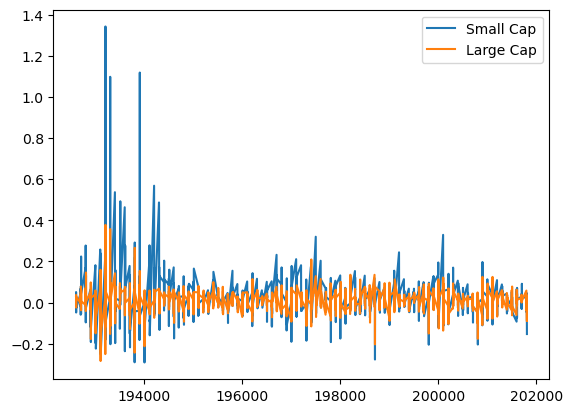

In [20]:
returns.plot()

In [21]:
returns.std()

Small Cap    0.106288
Large Cap    0.053900
dtype: float64

In [22]:
annualized_volatility = returns.std() * np.sqrt(12)
annualized_volatility

Small Cap    0.368193
Large Cap    0.186716
dtype: float64

In [29]:
return_per_month = (returns + 1).prod() ** (1 / len(returns)) - 1
return_per_month

Small Cap    0.012986
Large Cap    0.007423
dtype: float64

In [30]:
annualized_volatility

Small Cap    0.368193
Large Cap    0.186716
dtype: float64

In [31]:
annualized_return = (return_per_month + 1) ** 12 - 1
annualized_return

Small Cap    0.167463
Large Cap    0.092810
dtype: float64

In [32]:
annualized_return / annualized_volatility

Small Cap    0.454825
Large Cap    0.497063
dtype: float64

In [33]:
risk_free_rate = 0.03
excess_return = annualized_return - risk_free_rate
sharpe_ratio = excess_return / annualized_volatility
sharpe_ratio

Small Cap    0.373346
Large Cap    0.336392
dtype: float64